# Week 13 Project 4: Predictive Analysis using scikit-learn

**Student:** Daniel Foulen  

**Class:** IS 362  

**Date:** 4/30/2026

## Background
This notebook builds on the preprocessing work completed in HW8, where the UCI Mushroom dataset was loaded, subsetted to three columns (edibility, odor, bruises), and explored through EDA. 

That work suggested odor is a near-perfect predictor of edibility, while bruises shows signal but with substantial class overlap.

The goal here is to test that hypothesis formally. Using scikit-learn classifiers to determine which predictor, odor or bruises, more accurately predicts whether a mushroom is poisonous.

I use both Logistic Regression and Random Forest to classify the data into binary states (poisonous/edible), then compare them to each other. As a bit of an extra, I compare these two to Random Forest with four features to test dominance.

It's important to note the UCI mushroom dataset is... Very clean. I wonder how this would look on more unstructured data.

## Applications
Classification problems like this appear in food safety, medical diagnosis, and fraud detection. Any domain where a binary outcome matters and feature selection affects model reliability. Understanding which features can make or break a predictive analysis. 

Whether simpler models agree with more complex ones, is a core skill in applied machine learning.

---

## Step 1: Import Libraries

- **pandas**: dataframes
- **matplotlib.pyplot**: backend renderer required by seaborn
- **seaborn**: bar charts
- **LogisticRegression**: linear decision binary model
- **RandomForestClassifier**: non-linear decision tree model, useful for feature importance
- **train_test_split**: partitions the dataset into training and test sets
- **accuracy_score**: computes the fraction of correctly classified test samples
- **ucimlrepo**: UC Irvine's ML Repository client

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from ucimlrepo import fetch_ucirepo

## Step 2: Load and Reconstruct the DataFrame

We re-run the load from HW8 and recreate the dataframe from the online dataset. Anyone with the library installed can reproduce every result without needing a local data file (and also makes my life much easier. I don't want to have to load in or export CSVs).

`fetch_ucirepo(id=73)` returns the Mushroom dataset (UCI ID 73). The features (`X`) and target (`y`) arrive as separate DataFrames, so we concatenate them, subset to the three columns of interest, rename for readability, and integer-encode the target (`e` -> 0 for edible, `p` -> 1 for poisonous). 

Integer encoding is correct for the target. Scikit-learn classifiers expect a numeric `y`, and 0/1 carries no false ordering because it is not used as a feature.

In [2]:
# Fetch dataset (id=73 is the UCI Mushroom dataset)
mushroom = fetch_ucirepo(id=73)

X_raw = mushroom.data.features
y_raw = mushroom.data.targets

# Combine into one DataFrame for easier subsetting
df_full = pd.concat([y_raw, X_raw], axis=1)

# Subset to the three columns from HW8
df = df_full[['poisonous', 'odor', 'bruises']].copy()
df.columns = ['edibility', 'odor', 'bruises']

# Encode target: edible=0, poisonous=1
df['edibility'] = df['edibility'].map({'e': 0, 'p': 1})

print(df.shape)
print(df['edibility'].value_counts())
df.head()

(8124, 3)
edibility
0    4208
1    3916
Name: count, dtype: int64


,edibility,odor,bruises
0,1,p,t
1,0,a,t
2,0,l,t
3,1,p,t
4,0,n,f


## Step 3: One-Hot Encode the Predictors

**Why `get_dummies()` instead of `.map()` (which we used in HW8)?**  

In HW8 we used `.map()` to convert categorical strings to integer codes (e.g., `f`->0, `n`->1, `l`->2, ...) for EDA purposes. 

That is fine for counting and plotting, but scikit-learn classifiers treat those integers as having *ordinal* meaning: `odor=4` would be interpreted as "greater than" `odor=2`, implying a numerical relationship that does not exist. 

Odor categories are nominal. Foul is not twice as much as almond. One-hot encoding converts each category into a separate binary column (0 or 1), which eliminates any false ordering and lets the model treat each category independently.

**Why `drop_first=True`?**  

Odor has 9 unique values. Without dropping, one-hot encoding produces 9 binary columns that always sum to exactly 1 for every row. If the first 8 are all 0, the 9th must be 1. This perfect linear dependence is called multicollinearity, and it breaks Logistic Regression's matrix math (the coefficient matrix becomes singular and cannot be inverted). 

Dropping one column removes the redundancy while preserving all information. The dropped category is implicitly represented whenever all remaining dummies are 0. Random Forest does not require this because it does not invert matrices, but we apply `drop_first=True` to both encodings so the comparison between models is fair and the practice is statistically correct.

In [3]:
# One-hot encode odor (9 categories -> 8 columns after drop_first)
X_odor = pd.get_dummies(df['odor'], prefix='odor', drop_first=True)
print("Odor encoded shape:", X_odor.shape)
X_odor.head()

Odor encoded shape: (8124, 8)


,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y
0,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False
4,False,False,False,False,True,False,False,False


In [4]:
# One-hot encode bruises (binary: t/f -> 1 column after drop_first)
X_bruises = pd.get_dummies(df['bruises'], prefix='bruises', drop_first=True)
print("Bruises encoded shape:", X_bruises.shape)
X_bruises.head()

Bruises encoded shape: (8124, 1)


,bruises_t
0,True
1,True
2,True
3,True
4,False


## Step 4: One Train/Test Split

Both models must train and evaluate on identical data splits to make their accuracy scores directly comparable. If we called `train_test_split` separately for each predictor, differences in scores could reflect random variation in the split rather than real differences in predictive power.

The solution is to split once on the DataFrame index and then apply those same row indices to whichever feature matrix we need. `random_state=67` makes the split deterministic: without it, results change between runs, which is a problem when the class balance is slightly uneven (as EDA in HW8 showed more edible samples than poisonous). 

A fixed seed ensures that the train/test ratio of each class stays constant across runs.

In [5]:
y = df['edibility']

# Split on the index once; apply to both feature sets
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=67
)

print(f"Train rows: {len(train_idx)} | Test rows: {len(test_idx)}")
print(f"Train class balance:\n{y.loc[train_idx].value_counts()}")
print(f"\nTest class balance:\n{y.loc[test_idx].value_counts()}")

Train rows: 6499 | Test rows: 1625
Train class balance:
edibility
0    3342
1    3157
Name: count, dtype: int64

Test class balance:
edibility
0    866
1    759
Name: count, dtype: int64


The 80/20 split reserves a held-out portion of the dataset for final evaluation. 

Because `random_state=67` is fixed, the same rows are assigned to train and test on every run, making results reproducible. Both the odor and bruises models, and later the expanded model, will train and evaluate on these exact same indices, so their accuracy scores reflect predictor differences, not split variation.

## Step 5: Logistic Regression on Odor

Logistic Regression fits a linear boundary in the feature space. With odor one-hot encoded to 8 columns after `drop_first`, the solver must estimate 8 coefficients plus a bias term. More features mean the optimizer needs more iterations to converge on a stable solution.

**`max_iter=1000`**: The default of 100 iterations seems low. Raising to 1000 gives the solver enough room to converge cleanly on this dataset.  

**`random_state=67`**: Some solvers use random initialization, fixing the seed ensures reproducibility across runs.

In [6]:
lr_odor = LogisticRegression(max_iter=1000, random_state=67)
lr_odor.fit(X_odor.loc[train_idx], y.loc[train_idx])

lr_odor_acc = accuracy_score(y.loc[test_idx], lr_odor.predict(X_odor.loc[test_idx]))
print(f"Logistic Regression | Odor | Test Accuracy: {lr_odor_acc:.4f}")

Logistic Regression | Odor | Test Accuracy: 0.9809


Logistic Regression on odor achieves near-perfect accuracy on the test set. This means the linear boundary in the 8-column one-hot space is almost sufficient to separate poisonous from edible mushrooms on its own. 

Very few test rows are misclassified. The result directly confirms the near-perfect class separation observed visually in HW8's EDA.

## Step 6: Logistic Regression on Bruises

Bruises is a binary feature (bruises present or absent), so after `drop_first=True` it encodes to a single column. 

With only one feature, the solver converges very quickly. There is essentially one coefficient to estimate.

In [7]:
lr_bruises = LogisticRegression(max_iter=1000, random_state=67)
lr_bruises.fit(X_bruises.loc[train_idx], y.loc[train_idx])

lr_bruises_acc = accuracy_score(y.loc[test_idx], lr_bruises.predict(X_bruises.loc[test_idx]))
print(f"Logistic Regression | Bruises | Test Accuracy: {lr_bruises_acc:.4f}")

Logistic Regression | Bruises | Test Accuracy: 0.7403


Logistic Regression on bruises scores considerably lower than odor, meaningfully above random chance and above the majority-class baseline, but still far short of a reliable classifier. 

The model picks up the directional signal (bruised mushrooms tend toward edible) but cannot handle the substantial class overlap that HW8 showed. 

The gap between odor and bruises accuracy is the core finding of this assignment.

Let's try Random Forest Classification now.

## Step 7: Random Forest on Odor

Random Forest builds an ensemble of decision trees, each trained on a bootstrap sample of the data and a random subset of features at each split. The final prediction is a majority vote across all trees.

**`n_estimators=100`**: The standard default. 100 trees is sufficient for a dataset of this size (~8,000 rows, 8 features). More trees would likely induce severe overfitting on already structured data.

**`n_jobs=-1`**: Letting `n_jobs=-1` uses all available CPU cores. No effect on outputs, just makes it faster. I paid for all 14 cores, so I'll use all 14 cores.

**`random_state=67`**: RF uses randomness in two places: (1) the bootstrap sample drawn for each tree, and (2) the random subset of features considered at each split node. Fixing the seed makes both sources deterministic, ensuring the same forest is built on every run.

**Feature importances**: 

RF tracks how much each feature reduces impurity (Gini impurity by default) across all split nodes and all trees, averaged and normalized to sum to 1. 

A higher importance score means that column does more of the work in separating poisonous from edible mushrooms. 

For one-hot encoded odor, each binary column represents one odor category, so the importance scores tell us which specific odors are the strongest single predictors.

Random Forest | Odor | Train Accuracy: 0.9863 | Test Accuracy: 0.9809


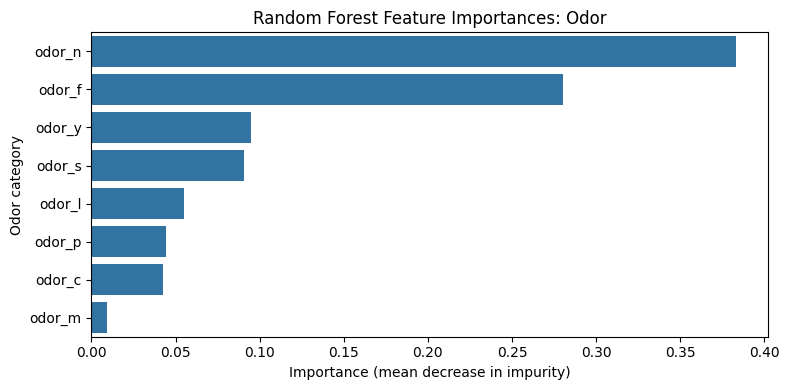

In [8]:
rf_odor = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
rf_odor.fit(X_odor.loc[train_idx], y.loc[train_idx])

rf_odor_train_acc = accuracy_score(y.loc[train_idx], rf_odor.predict(X_odor.loc[train_idx]))
rf_odor_acc = accuracy_score(y.loc[test_idx], rf_odor.predict(X_odor.loc[test_idx]))
print(f"Random Forest | Odor | Train Accuracy: {rf_odor_train_acc:.4f} | Test Accuracy: {rf_odor_acc:.4f}")

# Feature importances
odor_importances = pd.Series(
    rf_odor.feature_importances_, index=X_odor.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=odor_importances.values, y=odor_importances.index, ax=ax)
ax.set_title("Random Forest Feature Importances: Odor")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Odor category")
plt.tight_layout()
plt.show()

## Step 8: Random Forest on Bruises

Fitting Random Forest on the bruises predictor follows the same configuration as Step 7. 

Because bruises encodes to a single binary column after `drop_first=True`, the feature importance for that one column will always be 1.0. it is the only feature available, so 100% of the impurity reduction is attributed to it by definition. 

This is expected and does not indicate the feature is perfectly predictive, it most likely means there is nothing else to distribute importance to.

Random Forest | Bruises | Train Accuracy: 0.7449 | Test Accuracy: 0.7403


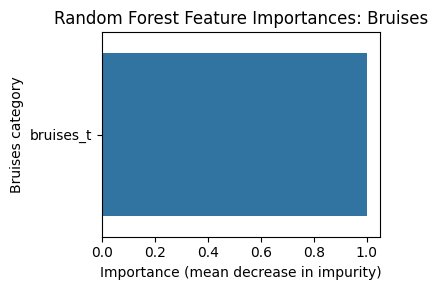

In [9]:
rf_bruises = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
rf_bruises.fit(X_bruises.loc[train_idx], y.loc[train_idx])

rf_bruises_train_acc = accuracy_score(y.loc[train_idx], rf_bruises.predict(X_bruises.loc[train_idx]))
rf_bruises_acc = accuracy_score(y.loc[test_idx], rf_bruises.predict(X_bruises.loc[test_idx]))
print(f"Random Forest | Bruises | Train Accuracy: {rf_bruises_train_acc:.4f} | Test Accuracy: {rf_bruises_acc:.4f}")

# Feature importances (single column: importance will be 1.0)
bruises_importances = pd.Series(
    rf_bruises.feature_importances_, index=X_bruises.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=bruises_importances.values, y=bruises_importances.index, ax=ax)
ax.set_title("Random Forest Feature Importances: Bruises")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Bruises category")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

## Step 9: Random Forest on Four Features (Extra)

Now for the fun part.

The isolated RF runs in Steps 7 and 8 answered the assignment question, which of these two predictors is better, but each model had nothing to compete against.

This step adds two more features so RF must allocate importance across a richer feature set, making the importance scores meaningfully comparative.

**Why 4 features instead of all 22?** 

The mushroom dataset is unusually clean and well-structured. Several individual features near-perfectly predict edibility on their own. 

When I used all 22 features just to see what would happen, it produced 100% test accuracy -- very much not fun and really not informative. 

It told us nothing useful about how the features relate to each other, except confirming the dataset is separable. 

Four features gives RF something real to compete across without trivializing the problem.

**Why gill-size and cap-color?** 

Gill-size is binary (broad vs. narrow) with moderate signal for edibility. Cap-color has 10 unique values and correlates with edibility imperfectly... neither feature strongly predicts the target on its own, but both add meaningful complexity to the comparison. 

Together they create a realistic competition where odor's dominance should be visible, but not the only story.

**What the importance chart now shows that the isolated runs could not:** 

When features compete, importance reflects relative contribution. In Steps 7 and 8, each isolated RF had 100% of its importance to distribute within a single feature. 

Those charts described internal structure, not relative strength. Here, odor and bruises are in the same model at the same time. How much odor dominates, and how much gill-size and cap-color contribute, is now visible in a single chart.

We reuse the same `train_idx` and `test_idx` from Step 4 so test accuracy is directly comparable to Steps 7 and 8.

Random Forest | 4 Features | Train Accuracy: 0.9932 | Test Accuracy: 0.9877


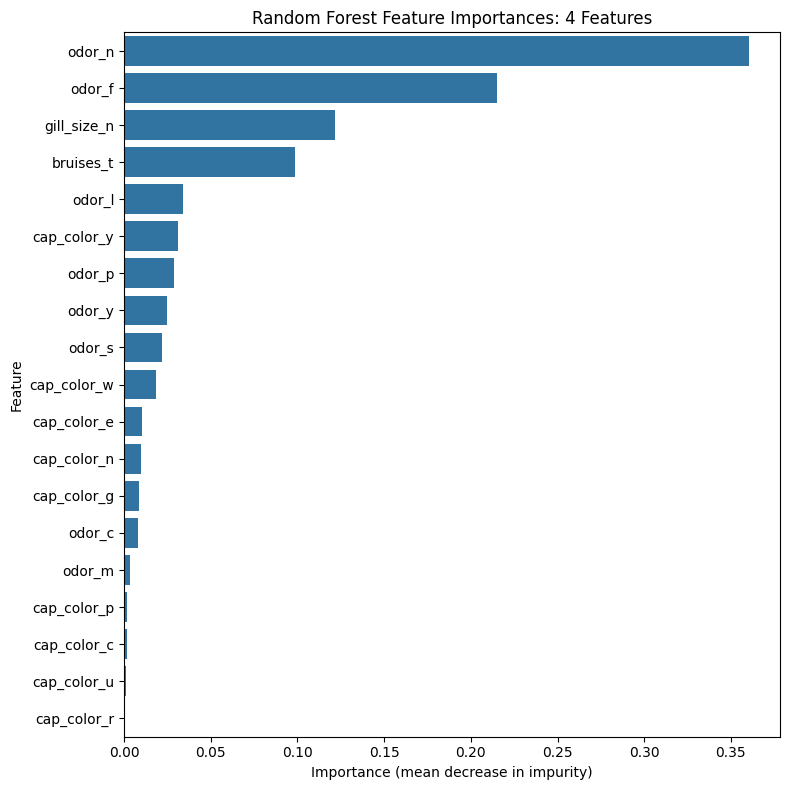

In [10]:
# One-hot encode each of the four features from the full dataset
odor_enc      = pd.get_dummies(df_full['odor'],      prefix='odor',      drop_first=True)
bruises_enc   = pd.get_dummies(df_full['bruises'],   prefix='bruises',   drop_first=True)
gill_size_enc = pd.get_dummies(df_full['gill-size'], prefix='gill_size', drop_first=True)
cap_color_enc = pd.get_dummies(df_full['cap-color'], prefix='cap_color', drop_first=True)

X_expanded = pd.concat([odor_enc, bruises_enc, gill_size_enc, cap_color_enc], axis=1)

# Reuse the exact same split indices from Step 4
rf_expanded = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=67)
rf_expanded.fit(X_expanded.loc[train_idx], y.loc[train_idx])

rf_expanded_train_acc = accuracy_score(y.loc[train_idx], rf_expanded.predict(X_expanded.loc[train_idx]))
rf_expanded_acc = accuracy_score(y.loc[test_idx], rf_expanded.predict(X_expanded.loc[test_idx]))
print(f"Random Forest | 4 Features | Train Accuracy: {rf_expanded_train_acc:.4f} | Test Accuracy: {rf_expanded_acc:.4f}")

# Horizontal layout -- cleaner with multiple named feature groups
expanded_importances = pd.Series(
    rf_expanded.feature_importances_, index=X_expanded.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=expanded_importances.values, y=expanded_importances.index, ax=ax)
ax.set_title("Random Forest Feature Importances: 4 Features")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Step 10: Summary Table

The table below collects all accuracy scores side by side. The Logistic Regression column is labeled **(Isolated Predictor Only)** to make clear those runs were single-feature models. The Expanded (4 Features) row is RF only -- a comparable LR was not fit because that multi-feature comparison is not part of the assignment.

In [11]:
summary = pd.DataFrame({
    'Predictor': ['Odor (isolated)', 'Bruises (isolated)', 'Expanded (4 Features)'],
    'Logistic Regression Accuracy (Isolated Predictor Only)': [
        f'{lr_odor_acc:.4f}', f'{lr_bruises_acc:.4f}', 'N/A'
    ],
    'Random Forest Accuracy': [
        f'{rf_odor_acc:.4f}', f'{rf_bruises_acc:.4f}', f'{rf_expanded_acc:.4f}'
    ]
})

summary

,Predictor,Logistic Regression Accuracy (Isolated Predictor Only),Random Forest Accuracy
0,Odor (isolated),0.9809,0.9809
1,Bruises (isolated),0.7403,0.7403
2,Expanded (4 Features),N/A,0.9877


## Conclusions

**Which predictor won?**

Odor, decisively. Both Logistic Regression and Random Forest scored 0.9809 on odor vs 0.7403 on bruises. That's a gap of ~24 percentage points. Bruises clears the majority-class baseline (~52% edible) but doesn't come close to odor's near-perfect separation.

**LR and RF agreed exactly.**

Identical test accuracy for both predictors. This tells us something: the relationship between each feature and edibility is linear enough that a simple model captures it fully. RF's ability to model complex interactions added nothing. When two structurally different classifiers produce the same result, you can be confident the finding is about the data, not the model.

**Connection to HW8 EDA:**

The EDA in HW8 showed that foul, creosote, fishy, musty, pungent, and spicy odors appeared exclusively in poisonous mushrooms. Almond and anise appeared exclusively in edible ones. Only "none" showed real class mixing. The 98% accuracy confirms that visual intuition, the model's errors are concentrated in the "none" category, exactly where the EDA predicted ambiguity.

Bruises told a similar story. The HW8 countplot showed directional skew (bruised mushrooms lean towards edible) but heavy overlap in both categories. 74% accuracy reflects that signal exists, but it's not clean enough to classify reliably alone.

**What the 4-feature RF revealed:**

Running RF on odor, bruises, gill-size, and cap-color simultaneously produced 0.9877 accuracy, a modest gain over odor alone. More interesting is the importance ranking: `odor_n` and `odor_f` still dominate, but `gill_size_n` (0.122) outranked `bruises_t` (0.098). When given a fair competition, gill-size carries more predictive weight than bruises does.

When bruises was the only feature, its importance was 1.0 by definition. In context, it ranks fourth.

**Further analysis:**

This dataset is unusually clean. Several single features nearly perfectly predict edibility, and even modest multi-feature models approach 100%. A more informative next step would be applying these same methods to a noisier dataset, one where features overlap more and model choice actually matters. 